<a href="https://colab.research.google.com/github/lalitkpal/DeepLearningPractice/blob/master/ML_for_WC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training error: Overfitting vs Accuracy?

Polynomial Curve Fitting with different orders.

Polynomial degree 0 coefficients:
[0.07380232] 

Polynomial degree 1 coefficients:
[-1.50188406  0.82474435] 

Polynomial degree 3 coefficients:
[ 21.98151741 -32.98208399  11.01839237   0.0634364 ] 

Polynomial degree 9 coefficients:
[-3.07322957e+04  1.35079645e+05 -2.48114141e+05  2.47118667e+05
 -1.44912911e+05  5.08844988e+04 -1.03921165e+04  1.11051137e+03
 -4.19938626e+01  1.76405235e-01] 



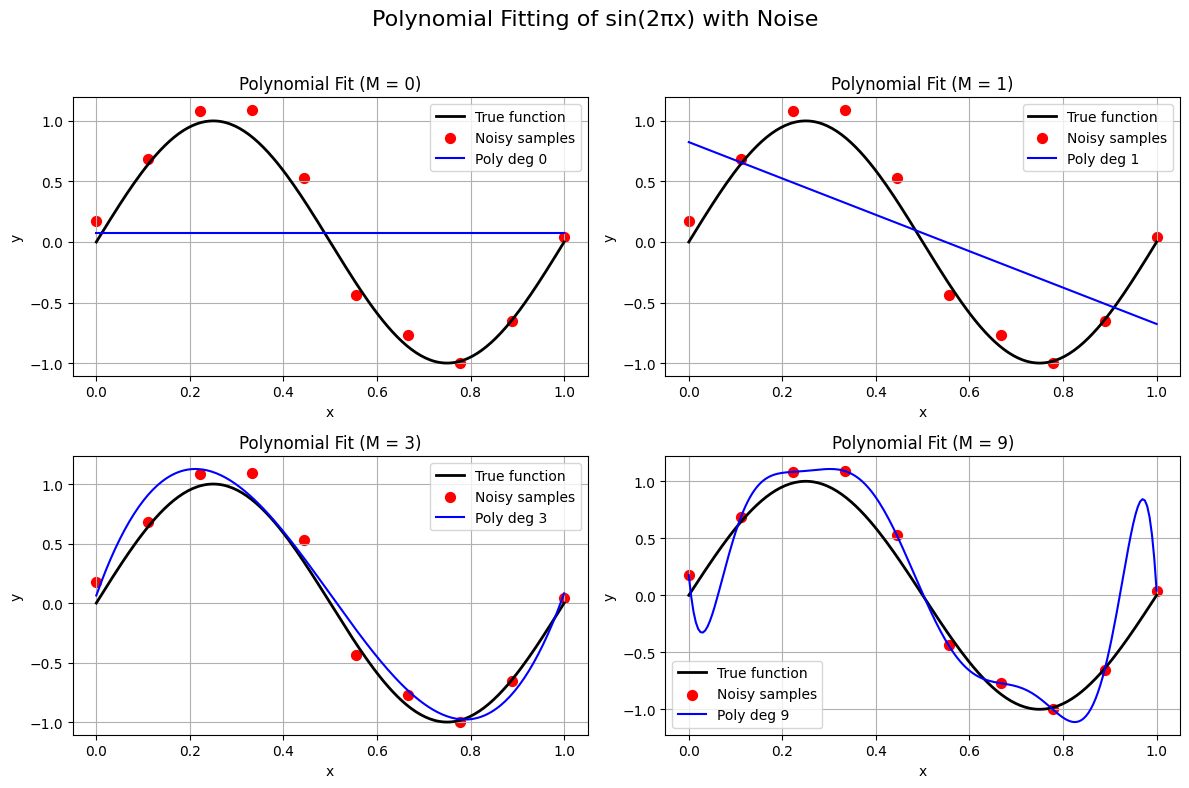

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(0)

# Define sampling
N = 10                                # number of sample points
x = np.linspace(0, 1, N)              # uniform sampling in [0,1]
y_true = np.sin(2 * np.pi * x)        # true function
noise = np.random.randn(N) * 0.1      # Gaussian noise (mean=0, std=0.1)
y_noisy = y_true + noise              # noisy samples

# Define polynomial orders
orders = [0, 1, 3, 9]

# Dense grid for plotting
x_dense = np.linspace(0, 1, 200)
y_dense_true = np.sin(2 * np.pi * x_dense)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, M in enumerate(orders):
    # Polynomial fitting
    coeffs = np.polyfit(x, y_noisy, M)
    y_fit = np.polyval(coeffs, x_dense)

    # Print coefficients
    print(f"Polynomial degree {M} coefficients:")
    print(coeffs, "\n")

    # Plot
    axes[i].plot(x_dense, y_dense_true, 'k-', linewidth=2, label='True function')
    axes[i].scatter(x, y_noisy, c='r', s=50, label='Noisy samples')
    axes[i].plot(x_dense, y_fit, 'b-', linewidth=1.5, label=f'Poly deg {M}')

    axes[i].legend(loc='best')
    axes[i].set_title(f'Polynomial Fit (M = {M})')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')
    axes[i].grid(True)

fig.suptitle('Polynomial Fitting of sin(2πx) with Noise', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


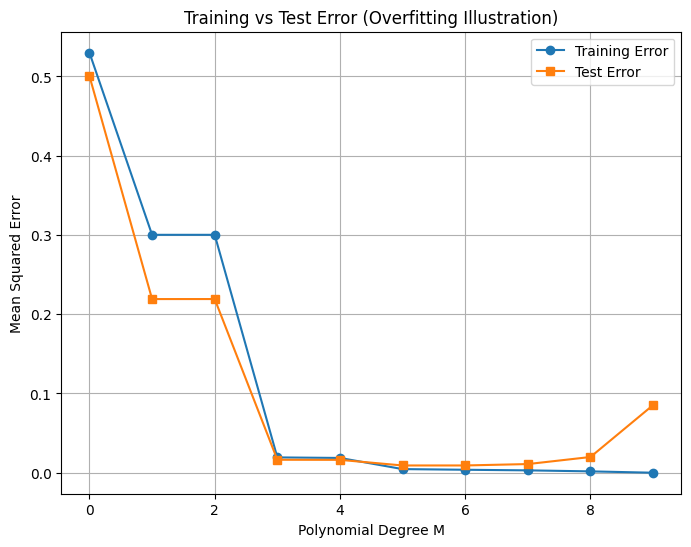

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(0)

# Training data (10 points with noise)
N_train = 10
x_train = np.linspace(0, 1, N_train)
y_true_train = np.sin(2 * np.pi * x_train)
noise = np.random.randn(N_train) * 0.1
y_train = y_true_train + noise

# Test data (100 clean points, no noise)
N_test = 100
x_test = np.linspace(0, 1, N_test)
y_test = np.sin(2 * np.pi * x_test)

# Polynomial orders to test
orders = range(0, 10)   # M = 0 to 9

train_errors = []
test_errors = []

for M in orders:
    coeffs = np.polyfit(x_train, y_train, M)

    # Predictions
    y_pred_train = np.polyval(coeffs, x_train)
    y_pred_test = np.polyval(coeffs, x_test)

    # Mean squared errors
    train_mse = np.mean((y_train - y_pred_train)**2)
    test_mse = np.mean((y_test - y_pred_test)**2)

    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Plot error vs polynomial degree
plt.figure(figsize=(8,6))
plt.plot(orders, train_errors, 'o-', label='Training Error')
plt.plot(orders, test_errors, 's-', label='Test Error')
plt.xlabel('Polynomial Degree M')
plt.ylabel('Mean Squared Error')
plt.title('Training vs Test Error (Overfitting Illustration)')
plt.legend()
plt.grid(True)
plt.show()


Impact of the size of the training set

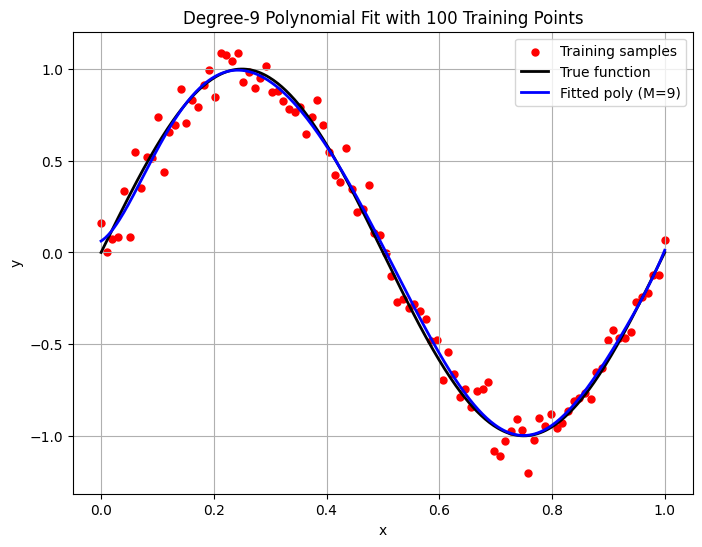

Polynomial degree 9 coefficients:
[ 3.79816158e+02 -1.15613624e+03  9.22505267e+02  6.09163468e+02
 -1.55430623e+03  1.16924136e+03 -4.37032630e+02  6.48205265e+01
  1.87803011e+00  6.22162983e-02]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(1)

# Training data (100 points with noise)
N_train = 100
x_train = np.linspace(0, 1, N_train)
y_true_train = np.sin(2 * np.pi * x_train)
noise = np.random.randn(N_train) * 0.1
y_train = y_true_train + noise

# Polynomial degree
M = 9

# Fit polynomial
coeffs = np.polyfit(x_train, y_train, M)

# Dense grid for smooth plotting
x_dense = np.linspace(0, 1, 400)
y_dense_true = np.sin(2 * np.pi * x_dense)
y_fit = np.polyval(coeffs, x_dense)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(x_train, y_train, c='r', s=25, label='Training samples')
plt.plot(x_dense, y_dense_true, 'k-', linewidth=2, label='True function')
plt.plot(x_dense, y_fit, 'b-', linewidth=2, label=f'Fitted poly (M={M})')

plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Degree-{M} Polynomial Fit with 100 Training Points')
plt.legend()
plt.grid(True)
plt.show()

# Print coefficients
print(f"Polynomial degree {M} coefficients:")
print(coeffs)


Regularization/Ridge Regression

Lambda=1.52e-08, coefficients:
[   1.88248065   30.97074065 -140.12468691  136.52118355   59.80357104
 -111.54971449  -53.69708468  122.19598894  -46.18630832] 

Lambda=1.00e+00, coefficients:
[-0.46859353 -0.43393665 -0.28286083 -0.14069336 -0.02777247  0.05811823
  0.1229107   0.17198874  0.20948896] 



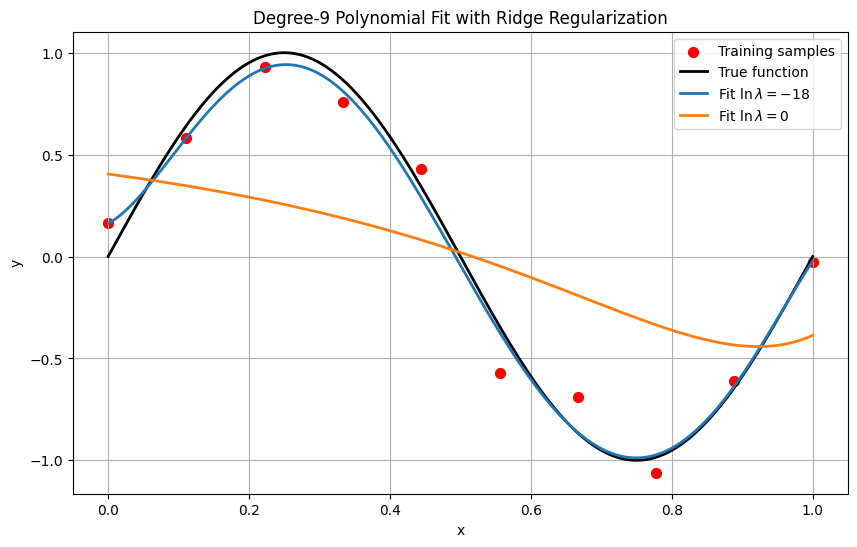

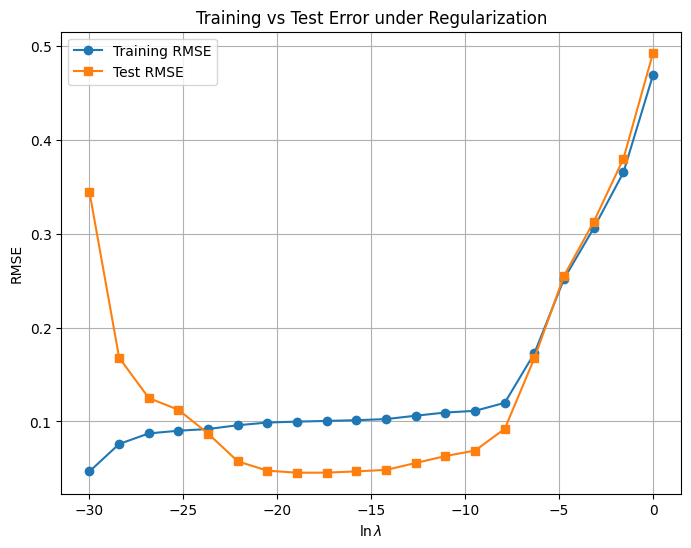

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

# Reproducibility
np.random.seed(1)

# Training data (10 noisy points)
N_train = 10
x_train = np.linspace(0, 1, N_train).reshape(-1, 1)
y_true_train = np.sin(2 * np.pi * x_train).ravel()
noise = np.random.randn(N_train) * 0.1
y_train = y_true_train + noise

# Test data (100 clean points)
N_test = 100
x_test = np.linspace(0, 1, N_test).reshape(-1, 1)
y_test = np.sin(2 * np.pi * x_test).ravel()

# Dense grid for plotting fitted curves
x_dense = np.linspace(0, 1, 400).reshape(-1, 1)
y_dense_true = np.sin(2 * np.pi * x_dense).ravel()

# Polynomial degree
M = 9
poly = PolynomialFeatures(degree=M, include_bias=False)
X_train_poly = poly.fit_transform(x_train)
X_test_poly = poly.transform(x_test)
X_dense_poly = poly.transform(x_dense)

# --- Part 1: Fits for ln λ = -18 and 0 ---
lambdas_special = [np.exp(-18), np.exp(0)]
labels = [r"$\ln \lambda = -18$", r"$\ln \lambda = 0$"]

plt.figure(figsize=(10,6))
plt.scatter(x_train, y_train, c='r', s=50, label="Training samples")
plt.plot(x_dense, y_dense_true, 'k-', linewidth=2, label="True function")

for lam, lab in zip(lambdas_special, labels):
    ridge = Ridge(alpha=lam, fit_intercept=True)
    ridge.fit(X_train_poly, y_train)
    y_fit = ridge.predict(X_dense_poly)
    plt.plot(x_dense, y_fit, linewidth=2, label=f'Fit {lab}')

    print(f"Lambda={lam:.2e}, coefficients:")
    print(ridge.coef_, "\n")

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Degree-{M} Polynomial Fit with Ridge Regularization")
plt.legend()
plt.grid(True)
plt.show()

# --- Part 2: Training vs Test error wrt λ ---
ln_lambdas = np.linspace(-30, 0, 20)  # range of ln λ
lambdas = np.exp(ln_lambdas)

train_errors = []
test_errors = []

for lam in lambdas:
    ridge = Ridge(alpha=lam, fit_intercept=True)
    ridge.fit(X_train_poly, y_train)

    y_pred_train = ridge.predict(X_train_poly)
    y_pred_test = ridge.predict(X_test_poly)

    train_rmse = np.sqrt(np.mean((y_train - y_pred_train)**2))
    test_rmse  = np.sqrt(np.mean((y_test  - y_pred_test)**2))

    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

plt.figure(figsize=(8,6))
plt.plot(ln_lambdas, train_errors, 'o-', label="Training RMSE")
plt.plot(ln_lambdas, test_errors, 's-', label="Test RMSE")
plt.xlabel(r"$\ln \lambda$")
plt.ylabel("RMSE")
plt.title("Training vs Test Error under Regularization")
plt.legend()
plt.grid(True)
plt.show()